In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

## 1. Data Collection

**1.1 Monthly returns**

In [2]:
prices_raw = pd.read_csv('QQQ_MAX_1MONTH_FROM_PERPLEXITY.csv',index_col = 0)

prices_raw.head()

,open,high,low,close,volume
date,,,,,
2026-02-27T00:00:00-05:00,602.98,608.32,602.19,607.29,68125196.0
2026-01-30T00:00:00-05:00,625.71,628.26,619.30,621.87,65650714.0
2025-12-31T00:00:00-05:00,619.65,619.96,614.05,614.31,40746527.0
2025-11-28T00:00:00-05:00,616.11,619.32,615.42,619.25,23034400.0
2025-10-31T00:00:00-04:00,634.17,634.20,626.69,629.07,66305147.0


In [3]:
import pandas as pd

pd.set_option("display.date_dayfirst", True)

# 1) Take the current index as a Series
idx = prices_raw.index.astype(str)

# 2) Cut off the 'T...' part, keep only the date
idx_date_only = idx.str.split('T').str[0]

# 3) Convert to datetime and assign back as a DatetimeIndex
prices_raw.index = pd.to_datetime(idx_date_only)

print(type(prices_raw.index))
print(prices_raw.index.dtype)
prices_raw

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
datetime64[ns]


,open,high,low,close,volume
date,,,,,
2026-02-27,602.98,608.32,602.19,607.29,68125196.0
2026-01-30,625.71,628.26,619.30,621.87,65650714.0
2025-12-31,619.65,619.96,614.05,614.31,40746527.0
2025-11-28,616.11,619.32,615.42,619.25,23034400.0
2025-10-31,634.17,634.20,626.69,629.07,66305147.0
...,...,...,...,...,...
2006-08-31,38.94,39.03,38.76,38.87,61215488.0
2006-07-31,37.08,37.32,36.89,37.10,78096496.0
2006-06-30,39.12,39.14,38.68,38.77,82721248.0


In [4]:
prices = prices_raw.rename(columns={'close':'Close'})
prices = prices['Close']
prices

date
2026-02-27    607.29
2026-01-30    621.87
2025-12-31    614.31
2025-11-28    619.25
2025-10-31    629.07
               ...  
2006-08-31     38.87
2006-07-31     37.10
2006-06-30     38.77
2006-05-31     38.82
2006-04-28     41.85
Name: Close, Length: 239, dtype: float64

In [5]:
ret = (prices
       .pct_change()  # Simple returns
       .iloc[1:-2]  # Drop first row (missing values), note the series 1-D formula
      )

ret

date
2026-01-30    0.024008
2025-12-31   -0.012157
2025-11-28    0.008042
2025-10-31    0.015858
2025-09-30   -0.045623
                ...   
2006-10-31   -0.033152
2006-09-29   -0.045326
2006-08-31   -0.043788
2006-07-31   -0.045536
2006-06-30    0.045013
Name: Close, Length: 236, dtype: float64

**1.2 Fama-French 3-factors (monthly)**

In [6]:
ffr = pd.read_csv('F-F_Research_Data_Factors.csv',index_col = 0)
ffr # in percentages

,Mkt-RF,SMB,HML,RF
Date (YYYYMM),,,,
192607,2.89,-2.55,-2.39,0.22
192608,2.64,-1.14,3.81,0.25
192609,0.38,-1.36,0.05,0.23
192610,-3.27,-0.14,0.82,0.32
192611,2.54,-0.11,-0.61,0.31
...,...,...,...,...
202508,1.84,3.87,4.42,0.38
202509,3.39,-1.85,-1.05,0.33
202510,1.96,-0.55,-3.09,0.37


In [7]:
from pandas.tseries.offsets import MonthEnd

ffr.index = pd.to_datetime(ffr.index.astype(str), format="%Y%m") + MonthEnd(0) # confusing syntax

ffr.index.name = "Date"
ffr

,Mkt-RF,SMB,HML,RF
Date,,,,
1926-07-31,2.89,-2.55,-2.39,0.22
1926-08-31,2.64,-1.14,3.81,0.25
1926-09-30,0.38,-1.36,0.05,0.23
1926-10-31,-3.27,-0.14,0.82,0.32
1926-11-30,2.54,-0.11,-0.61,0.31
...,...,...,...,...
2025-08-31,1.84,3.87,4.42,0.38
2025-09-30,3.39,-1.85,-1.05,0.33
2025-10-31,1.96,-0.55,-3.09,0.37


**1.3 Monthly Excess Returns**

In [8]:
RF = ffr['RF'] / 100

RF.index = pd.to_datetime(RF.index.astype(str), format='%Y-%m-%d') + pd.offsets.MonthEnd(0)

common_idx = ret.index.intersection(RF.index)
xret = ret.loc[common_idx].sub(RF.loc[common_idx])

xret = xret.to_frame()

xret

,0
2025-12-31,-0.015557
2025-10-31,0.012158
2025-09-30,-0.048923
2025-07-31,-0.012850
2025-06-30,-0.027063
...,...
2006-11-30,0.016189
2006-10-31,-0.037252
2006-08-31,-0.047988
2006-07-31,-0.049536


## 2. Regressing Excess Returns on the FF3 Factors

**2.1 Regression Specification**

## $$R
_t - R_f = \alpha_i + \beta_{MKT} + \beta_{SMB} + \beta_{HML} + \epsilon_{i,t}
$$

**2.2 Preparing Variables**

To prepare the right-hand side variables for the three-factor regression, we prepare the matrix of regressors.

In [9]:
F3 = sm.add_constant(ffr[['Mkt-RF', 'SMB', 'HML']] / 100)

We need to align the dates of the dependent and independent variables.

In [10]:
common_idx = xret.index.intersection(F3.index)
y = xret.loc[common_idx]
x3 = F3.loc[common_idx]

**2.3 Regression**

In [11]:
Reg3   = sm.OLS(y, x3).fit()

print(Reg3.summary())

                            OLS Regression Results                            
Dep. Variable:                      0   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.861
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.138
Time:                        13:58:14   Log-Likelihood:                 251.56
No. Observations:                 166   AIC:                            -495.1
Df Residuals:                     162   BIC:                            -482.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0105      0.004     -2.436      0.0

## 3. Robustness & Stability

**3.1 Rolling Regressions**

We use the rollingOLS method from statsmodels

In [12]:
from statsmodels.regression.rolling import RollingOLS

# Data is already aligned

# Fit rolling regression with 36-month window
rolling_mod = RollingOLS(y.values, x3.values, window=36)
rolling_res = rolling_mod.fit()

In [13]:
# params has shape (n_periods, n_params): [const, Mkt-RF, SMB, HML]
params = pd.DataFrame(
    rolling_res.params,
    index=common_idx,
    columns=['α', 'β_Mkt-RF', 'β_SMB', 'β_HML']
)

rolling_alpha = params['α']
rolling_betas = params[['β_Mkt-RF', 'β_SMB', 'β_HML']]
params.dropna()

,α,β_Mkt-RF,β_SMB,β_HML
2021-12-31,-0.015251,0.270431,-0.556623,0.454293
2021-11-30,-0.014691,0.267771,-0.556869,0.459403
2021-09-30,-0.017888,0.308808,-0.613534,0.429649
2021-08-31,-0.014932,0.359344,-0.644742,0.415727
2021-06-30,-0.014296,0.362103,-0.633269,0.394796
...,...,...,...,...
2006-11-30,-0.008483,-0.738941,0.900456,0.595749
2006-10-31,-0.009445,-0.746030,0.885776,0.601800
2006-08-31,-0.010388,-0.754823,0.902185,0.617481
2006-07-31,-0.011462,-0.764940,0.970421,0.586246


**3.2 Factor contribution decomposition**

##### $$
Contribution_{factor,t} = \beta_{factor} + Factor Return_{t}
$$

In [14]:
# Extracting variables
factor_returns = ffr[['Mkt-RF','SMB','HML']]
factor_betas = rolling_betas[['β_Mkt-RF', 'β_SMB', 'β_HML']]

# Extracting overlapping months
common_idx_fac_decomp = factor_betas.index.intersection(factor_returns.index)

# Filtering for common months
factor_returns = factor_returns.loc[common_idx_fac_decomp]
factor_betas = factor_betas.loc[common_idx_fac_decomp]

# Rename factor_returns columns to match factor_betas before multiplying
factor_betas.columns = ['Mkt-RF', 'SMB', 'HML']

# Multiply element-by-element (beta × factor return)
factor_contribution = factor_betas * factor_returns
factor_contribution.dropna()

,Mkt-RF,SMB,HML
2021-12-31,0.873494,0.907295,1.476453
2021-11-30,-0.423078,0.729499,-0.169979
2021-09-30,-1.358756,-0.404933,2.199805
2021-08-31,1.056473,0.206318,-0.095617
2021-06-30,0.992162,-1.076557,-3.103099
...,...,...,...
2006-11-30,-1.256199,0.567287,0.023830
2006-10-31,-2.402217,1.567824,-0.198594
2006-08-31,-1.532290,0.893163,-1.204087
2006-07-31,0.589004,-3.833165,1.535965


In [15]:
# Sum contributions
factor_contribution['Explained_Return'] = factor_contribution[['Mkt-RF', 'SMB', 'HML']].sum(axis=1)

# Residual calculation
common_idx_fac_decomp = factor_contribution.index.intersection(xret.index)
excess_returns = xret.loc[common_idx_fac_decomp]
factor_contribution['Excess_Return'] = excess_returns

# Align both series on the common index before subtracting
factor_contribution['Residual'] = excess_returns[0].sub(factor_contribution['Explained_Return'])

factor_contribution.dropna()

,Mkt-RF,SMB,HML,Explained_Return,Excess_Return,Residual
2021-12-31,0.873494,0.907295,1.476453,3.257241,0.095755,-3.161487
2021-11-30,-0.423078,0.729499,-0.169979,0.136442,-0.010129,-0.146571
2021-09-30,-1.358756,-0.404933,2.199805,0.436117,-0.072907,-0.509023
2021-08-31,1.056473,0.206318,-0.095617,1.167173,0.061431,-1.105742
2021-06-30,0.992162,-1.076557,-3.103099,-3.187494,-0.027814,3.159681
...,...,...,...,...,...,...
2006-11-30,-1.256199,0.567287,0.023830,-0.665082,0.016189,0.681271
2006-10-31,-2.402217,1.567824,-0.198594,-1.032986,-0.037252,0.995735
2006-08-31,-1.532290,0.893163,-1.204087,-1.843214,-0.047988,1.795226
2006-07-31,0.589004,-3.833165,1.535965,-1.708196,-0.049536,1.658660


## 4. Visualisation & Interpretation

**4.1 Monthly Excess Returns**

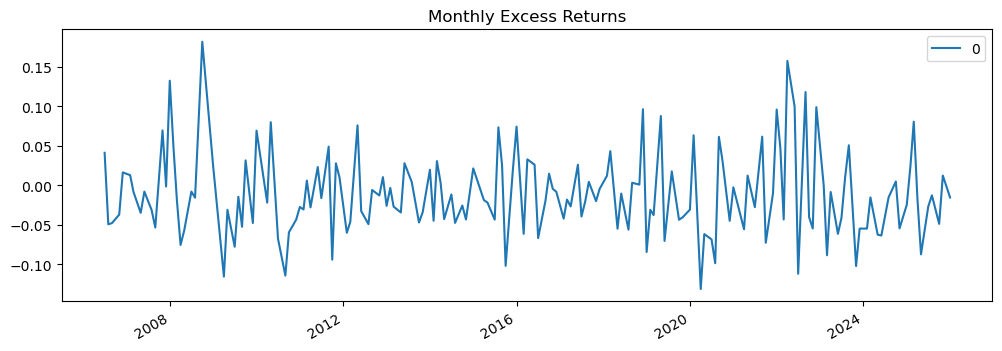

In [16]:
xret.plot(title='Monthly Excess Returns', figsize=(12, 4))
plt.show()

**4.2 Time Series of Rolling alpha and betas**

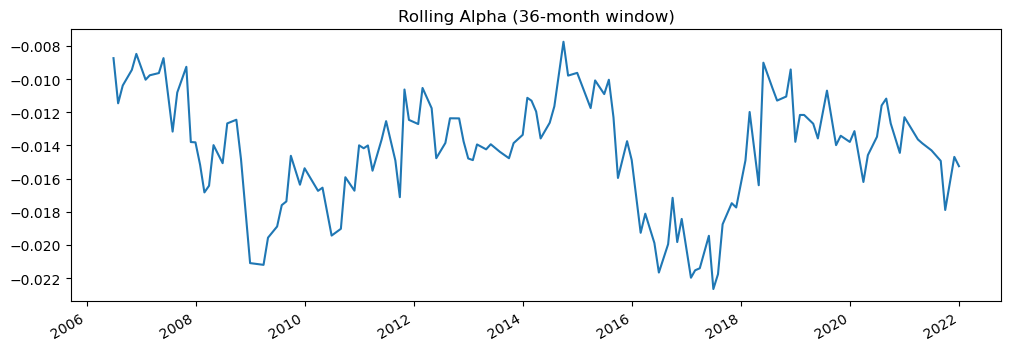

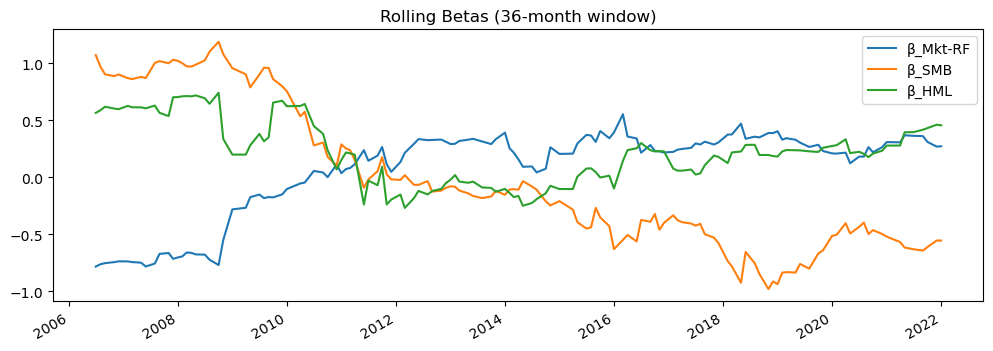

In [17]:
rolling_alpha.plot(title='Rolling Alpha (36-month window)', figsize=(12, 4))
plt.show()

rolling_betas.plot(title='Rolling Betas (36-month window)', figsize=(12, 4))
plt.show()

**4.3 Cumulative Explained vs Residual vs Excess Returns**

<Axes: title={'center': 'Cumulative Explained vs Residual vs Excess Return'}>

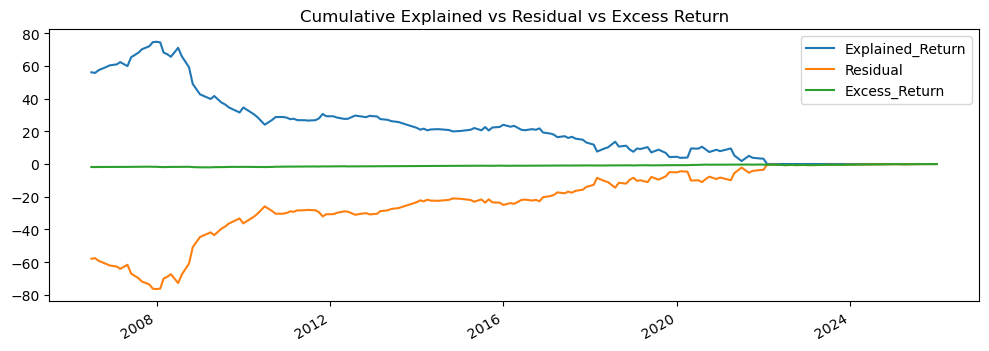

In [18]:
# Sort Oldest to Newest
cumulative_factor_contribution = factor_contribution.sort_index()

# Compute cumulative sums
cumulative_factor_contribution = factor_contribution[['Explained_Return', 'Residual', 'Excess_Return']].cumsum()
cumulative_factor_contribution.plot(title='Cumulative Explained vs Residual vs Excess Return', figsize=(12, 4))